**Deep Learning-based Brain Tumor Segmentation Using MRI**

Programming Assignment #2

CAP 5516 - Medical Image Computing (Spring 2026)



*Darinka Townsend*

# **Libraries**

In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

GPU available: True
Device: cuda


In [ ]:
!pip install nibabel
!pip install monai
!pip install medpy
!pip install scikit-learn
!pip install matplotlib
!pip install tqdm

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
from monai.transforms import (
    Compose,
    LoadImaged,
    NormalizeIntensityd,
    RandFlipd,
    RandRotate90d,
    ToTensord
)
from monai.networks.nets import UNet
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from medpy.metric import binary
from sklearn.model_selection import KFold
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import os
import numpy as np
import nibabel as nib
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from monai.networks.nets import UNet
import os
import glob
import numpy as np
import nibabel as nib
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import KFold
import torch
import torch.nn as nn
import torch.optim as optim
from monai.networks.nets import UNet
import torch
from monai.networks.nets import UNet

# **Dataset**

In [ ]:
!gdown --folder https://drive.google.com/drive/folders/1HqEgzS8BV2c7xYNrZdEAnrHk7osJJ--2

Retrieving folder contents
Processing file 18dLVTJtkp052danMjzlirAgIsklT_Aem license.txt
Processing file 1A2IU8Sgea1h3fYLpYtFb2v7NYdMjvEhU Task01_BrainTumour.tar
Processing file 1wEB2I6S6tQBVEPxir8cA5kFB8gTQadYY Task02_Heart.tar
Processing file 1jyVGUGyxKBXV6_9ivuZapQS8eUJXCIpu Task03_Liver.tar
Processing file 1RzPB1_bqzQhlWvU-YGvZzhx2omcDh38C Task04_Hippocampus.tar
Processing file 1Ff7c21UksxyT4JfETjaarmuKEjdqe1-a Task05_Prostate.tar
Processing file 1I1LR7XjyEZ-VBQ-Xruh31V7xExMjlVvi Task06_Lung.tar
Processing file 1YZQFSonulXuagMIfbJkZeTFJ6qEUuUxL Task07_Pancreas.tar
Processing file 1qVrpV7vmhIsUxFiH189LmAn0ALbAPrgS Task08_HepaticVessel.tar
Processing file 1jzeNU1EKnK81PyTsrx0ujfNl-t0Jo8uE Task09_Spleen.tar
Processing file 1m7tMpE9qEcQGQjL_BdMD-Mvgmc44hG1Y Task10_Colon.tar
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=18dLVTJtkp052danMjzlirAgIsklT_Aem
To: /content/MSD/license

In [ ]:
import tarfile

tar = tarfile.open("/content/MSD/Task01_BrainTumour.tar")
tar.extractall()
tar.close()

/tmp/ipykernel_1599/677006908.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [ ]:
data_root = "/content/Task01_BrainTumour"

images_dir = os.path.join(data_root, "imagesTr")
labels_dir = os.path.join(data_root, "labelsTr")
json_path = os.path.join(data_root, "dataset.json")

print("Images dir exists:", os.path.exists(images_dir))
print("Labels dir exists:", os.path.exists(labels_dir))
print("JSON exists:", os.path.exists(json_path))

image_files = sorted(glob.glob(os.path.join(images_dir, "*.nii.gz")))
label_files = sorted(glob.glob(os.path.join(labels_dir, "*.nii.gz")))

print("Num images:", len(image_files))
print("Num labels:", len(label_files))
print("First image:", image_files[0] if len(image_files) > 0 else "None")
print("First label:", label_files[0] if len(label_files) > 0 else "None")

Images dir exists: True
Labels dir exists: True
JSON exists: True
Num images: 484
Num labels: 484
First image: /content/Task01_BrainTumour/imagesTr/BRATS_001.nii.gz
First label: /content/Task01_BrainTumour/labelsTr/BRATS_001.nii.gz


In [ ]:
img_nii = nib.load(image_files[0])
lab_nii = nib.load(label_files[0])

img = img_nii.get_fdata()
lab = lab_nii.get_fdata()

print("Image shape:", img.shape)
print("Label shape:", lab.shape)
print("Image dtype:", img.dtype)
print("Label unique values:", np.unique(lab))

Image shape: (240, 240, 155, 4)
Label shape: (240, 240, 155)
Image dtype: float64
Label unique values: [0. 1. 2. 3.]


4D image detected.


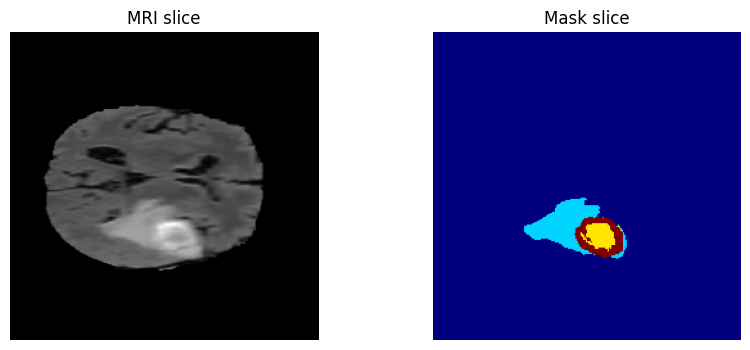

In [ ]:
if img.ndim == 4:
    print("4D image detected.")
    slice_idx = img.shape[2] // 2
    modality_idx = 0
    img_slice = img[:, :, slice_idx, modality_idx]
else:
    slice_idx = img.shape[2] // 2
    img_slice = img[:, :, slice_idx]

lab_slice = lab[:, :, slice_idx]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_slice, cmap="gray")
plt.title("MRI slice")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(lab_slice, cmap="jet")
plt.title("Mask slice")
plt.axis("off")

plt.show()

## **List of patients**

In [ ]:
patients = []
for img_path, lbl_path in zip(image_files, label_files):
    patients.append({
        "image": img_path,
        "label": lbl_path
    })

print("Total patients:", len(patients))
print(patients[0])

Total patients: 484
{'image': '/content/Task01_BrainTumour/imagesTr/BRATS_001.nii.gz', 'label': '/content/Task01_BrainTumour/labelsTr/BRATS_001.nii.gz'}


## **2D dataset slice-by-slice**

In [ ]:
data_root = "/content/Task01_BrainTumour"
images_dir = os.path.join(data_root, "imagesTr")
labels_dir = os.path.join(data_root, "labelsTr")

preprocessed_root = "/content/brats_2d_preprocessed"
images_out_dir = os.path.join(preprocessed_root, "images")
labels_out_dir = os.path.join(preprocessed_root, "labels")

os.makedirs(images_out_dir, exist_ok=True)
os.makedirs(labels_out_dir, exist_ok=True)

image_files = sorted(glob.glob(os.path.join(images_dir, "*.nii.gz")))
label_files = sorted(glob.glob(os.path.join(labels_dir, "*.nii.gz")))

print("Num images:", len(image_files))
print("Num labels:", len(label_files))

Num images: 484
Num labels: 484


In [ ]:
def remap_labels(lbl_slice):
    lbl_slice = lbl_slice.astype(np.int64)
    lbl_remap = np.zeros_like(lbl_slice)
    lbl_remap[lbl_slice == 1] = 1
    lbl_remap[lbl_slice == 2] = 2
    lbl_remap[lbl_slice == 4] = 3
    return lbl_remap

In [ ]:
modality_idx = 0
remove_empty_slices = True

metadata = []

for img_path, lbl_path in tqdm(list(zip(image_files, label_files)), total=len(image_files)):
    patient_id = os.path.basename(img_path).replace(".nii.gz", "")

    img = nib.load(img_path).get_fdata(dtype=np.float32)
    lbl = nib.load(lbl_path).get_fdata(dtype=np.float32)

    if img.ndim == 4:
        img = img[:, :, :, modality_idx]

    depth = img.shape[2]

    for z in range(depth):
        img_slice = img[:, :, z]
        lbl_slice = lbl[:, :, z]

        if remove_empty_slices and np.sum(lbl_slice) == 0:
            continue

        if img_slice.std() > 0:
            img_slice = (img_slice - img_slice.mean()) / img_slice.std()
        else:
            img_slice = img_slice - img_slice.mean()

        lbl_slice = remap_labels(lbl_slice)

        img_name = f"{patient_id}_slice_{z:03d}.npy"
        lbl_name = f"{patient_id}_slice_{z:03d}.npy"

        np.save(os.path.join(images_out_dir, img_name), img_slice.astype(np.float32))
        np.save(os.path.join(labels_out_dir, lbl_name), lbl_slice.astype(np.uint8))

        metadata.append({
            "patient_id": patient_id,
            "slice_idx": z,
            "image": os.path.join(images_out_dir, img_name),
            "label": os.path.join(labels_out_dir, lbl_name)
        })

print("Total saved slices:", len(metadata))

100%|██████████| 484/484 [05:34<00:00,  1.45it/s]

Total saved slices: 33755


In [ ]:
sample_img = np.load(metadata[0]["image"])
sample_lbl = np.load(metadata[0]["label"])

print("Image shape:", sample_img.shape)
print("Label shape:", sample_lbl.shape)
print("Label unique values:", np.unique(sample_lbl))

Image shape: (240, 240)
Label shape: (240, 240)
Label unique values: [0 1]


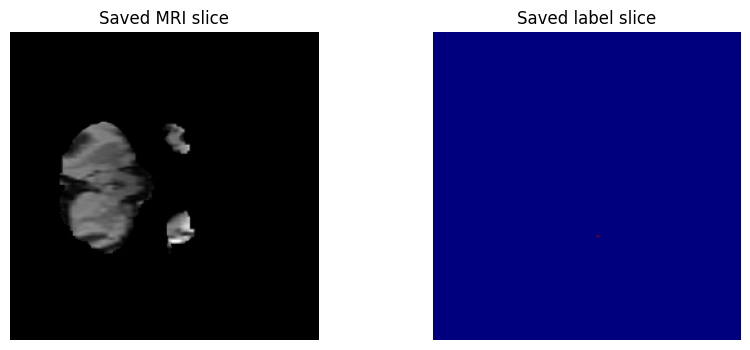

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample_img, cmap="gray")
plt.title("Saved MRI slice")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sample_lbl, cmap="jet")
plt.title("Saved label slice")
plt.axis("off")

plt.show()

## **Dataset 2D**

In [ ]:
class BrainTumor2DNPYDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]

        img = np.load(item["image"]).astype(np.float32)
        lbl = np.load(item["label"]).astype(np.int64)

        img = np.expand_dims(img, axis=0)  # [1,H,W]

        return (
            torch.tensor(img, dtype=torch.float32),
            torch.tensor(lbl, dtype=torch.long)
        )

# **Folds by Patients**

In [ ]:
patients = sorted(list(set([m["patient_id"] for m in metadata])))
print("Num patients:", len(patients))
print("First patient:", patients[0])

Num patients: 484
First patient: BRATS_001


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_splits = list(kf.split(patients))
print("Number of folds:", len(fold_splits))

Number of folds: 5


Construir samples de train/val por fold

In [ ]:
def get_samples_for_patients(patient_ids, metadata):
    patient_ids = set(patient_ids)
    return [m for m in metadata if m["patient_id"] in patient_ids]

fold = 0
train_idx, val_idx = fold_splits[fold]

train_patient_ids = [patients[i] for i in train_idx]
val_patient_ids   = [patients[i] for i in val_idx]

train_samples = get_samples_for_patients(train_patient_ids, metadata)
val_samples   = get_samples_for_patients(val_patient_ids, metadata)

print("Train samples:", len(train_samples))
print("Val samples:", len(val_samples))

Train samples: 26946
Val samples: 6809


# **DataLoaders**

In [ ]:
from torch.utils.data import DataLoader

train_dataset = BrainTumor2DNPYDataset(train_samples)
val_dataset   = BrainTumor2DNPYDataset(val_samples)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

x, y = next(iter(train_loader))
print("Batch image shape:", x.shape)
print("Batch mask shape:", y.shape)
print("Mask labels:", torch.unique(y))

Batch image shape: torch.Size([8, 1, 240, 240])
Batch mask shape: torch.Size([8, 240, 240])
Mask labels: tensor([0, 1, 2])


# **2D U-Net model**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=4,          # 0=background, 1,2,3=clases remapeadas
    channels=(16, 32, 64, 128),
    strides=(2, 2, 2),
    num_res_units=2
).to(device)

print(model)

Using device: cuda
UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (adn): ADN(
            (N): InstanceNorm2d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (adn): ADN(
            (N): InstanceNorm2d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Sequential

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def build_unet():
    model = UNet(
        spatial_dims=2,
        in_channels=1,
        out_channels=4,
        channels=(16, 32, 64, 128),
        strides=(2, 2, 2),
        num_res_units=2
    ).to(device)
    return model

## **Loss + Optimizer**

In [ ]:
from monai.losses import DiceLoss
import torch.nn as nn
import torch.optim as optim

ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLoss(to_onehot_y=True, softmax=True)

def combined_loss(outputs, masks):
    return 0.5 * ce_loss(outputs, masks) + 0.5 * dice_loss(outputs, masks.unsqueeze(1))

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
x, y = next(iter(train_loader))

x = x.to(device)
y = y.to(device)

with torch.no_grad():
    out = model(x)

print("Input shape :", x.shape)     # [B, 1, H, W]
print("Mask shape  :", y.shape)     # [B, H, W]
print("Output shape:", out.shape)   # [B, 4, H, W]

Input shape : torch.Size([8, 1, 240, 240])
Mask shape  : torch.Size([8, 240, 240])
Output shape: torch.Size([8, 4, 240, 240])


# **Training**

In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0

    for batch_idx, (images, masks) in enumerate(loader):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f"Batch {batch_idx}/{len(loader)} - Loss: {loss.item():.4f}")

    return running_loss / len(loader)

# **Validation**

In [ ]:
def validate_one_epoch(model, loader, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = combined_loss(outputs, masks)
            running_loss += loss.item()

    return running_loss / len(loader)

# **Loop**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

num_epochs = 15
history = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss = validate_one_epoch(model, val_loader, device)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Batch 0/3369 - Loss: 1.1788
Batch 100/3369 - Loss: 0.4705
Batch 200/3369 - Loss: 0.3878
Batch 300/3369 - Loss: 0.3514
Batch 400/3369 - Loss: 0.3715
Batch 500/3369 - Loss: 0.3470
Batch 600/3369 - Loss: 0.3518
Batch 700/3369 - Loss: 0.3360
Batch 800/3369 - Loss: 0.3054
Batch 900/3369 - Loss: 0.3224
Batch 1000/3369 - Loss: 0.3084
Batch 1100/3369 - Loss: 0.3228
Batch 1200/3369 - Loss: 0.3195
Batch 1300/3369 - Loss: 0.3200
Batch 1400/3369 - Loss: 0.3133
Batch 1500/3369 - Loss: 0.3392
Batch 1600/3369 - Loss: 0.3066
Batch 1700/3369 - Loss: 0.3027
Batch 1800/3369 - Loss: 0.3023
Batch 1900/3369 - Loss: 0.3188
Batch 2000/3369 - Loss: 0.2878
Batch 2100/3369 - Loss: 0.3265
Batch 2200/3369 - Loss: 0.3170
Batch 2300/3369 - Loss: 0.2957
Batch 2400/3369 - Loss: 0.3137
Batch 2500/3369 - Loss: 0.3049
Batch 2600/3369 - Loss: 0.3092
Batch 2700/3369 - Loss: 0.2967
Batch 2800/3369 - Loss: 0.3112
Batch 2900/3369 - Loss: 0.2978
Batch 3000/3369 - Loss: 0.3125
Batch 3100/3369 - Loss: 0.2919
Batch 3200/3369 - Lo

In [ ]:
history_df = pd.DataFrame(history)
history_df.style.format({
    "train_loss": "{:.4f}",
    "val_loss": "{:.4f}"
})

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Training Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
history_df.to_excel("/content/loss_history.xlsx", index=False)

# **Review predictions**

In [ ]:
model.eval()

with torch.no_grad():
    x, y = next(iter(val_loader))
    x = x.to(device)

    out = model(x)
    pred = torch.argmax(out, dim=1)

print("Pred shape:", pred.shape)
print("Pred unique labels:", torch.unique(pred.cpu()))

In [ ]:
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
    x, y = next(iter(val_loader))
    x_gpu = x.to(device)

    out = model(x_gpu)
    pred = torch.argmax(out, dim=1).cpu()

idx = 0

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(x[idx, 0], cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(y[idx], cmap="jet", vmin=0, vmax=3)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred[idx], cmap="jet", vmin=0, vmax=3)
plt.title("Prediction")
plt.axis("off")

plt.show()

# **Metrics**

In [ ]:
import numpy as np
from medpy.metric import binary

def dice_score_binary(pred, target, eps=1e-8):
    pred = pred.astype(np.uint8)
    target = target.astype(np.uint8)

    intersection = np.sum(pred * target)
    return (2.0 * intersection + eps) / (np.sum(pred) + np.sum(target) + eps)

def hd95_safe(pred, target):
    pred = pred.astype(np.uint8)
    target = target.astype(np.uint8)

    if pred.sum() == 0 and target.sum() == 0:
        return 0.0
    if pred.sum() == 0 or target.sum() == 0:
        return np.nan

    return binary.hd95(pred, target)

def get_regions(mask):
    """
    mask con labels remapeados {0,1,2,3}
    devuelve ET, TC, WT en binario
    """
    et = (mask == 3).astype(np.uint8)
    tc = np.isin(mask, [1, 3]).astype(np.uint8)
    wt = np.isin(mask, [1, 2, 3]).astype(np.uint8)
    return et, tc, wt

# **Evaluation**

In [ ]:
def evaluate_segmentation_metrics(model, loader, device):
    model.eval()

    dice_et_list, dice_tc_list, dice_wt_list = [], [], []
    hd95_et_list, hd95_tc_list, hd95_wt_list = [], [], []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            preds_np = preds.cpu().numpy()
            masks_np = masks.cpu().numpy()

            for pred_mask, true_mask in zip(preds_np, masks_np):
                p_et, p_tc, p_wt = get_regions(pred_mask)
                t_et, t_tc, t_wt = get_regions(true_mask)

                dice_et_list.append(dice_score_binary(p_et, t_et))
                dice_tc_list.append(dice_score_binary(p_tc, t_tc))
                dice_wt_list.append(dice_score_binary(p_wt, t_wt))

                hd95_et_list.append(hd95_safe(p_et, t_et))
                hd95_tc_list.append(hd95_safe(p_tc, t_tc))
                hd95_wt_list.append(hd95_safe(p_wt, t_wt))

    results = {
        "Dice_ET": np.nanmean(dice_et_list),
        "Dice_TC": np.nanmean(dice_tc_list),
        "Dice_WT": np.nanmean(dice_wt_list),
        "HD95_ET": np.nanmean(hd95_et_list),
        "HD95_TC": np.nanmean(hd95_tc_list),
        "HD95_WT": np.nanmean(hd95_wt_list),
    }

    return results

In [ ]:
metrics = evaluate_segmentation_metrics(model, val_loader, device)

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

In [ ]:
import pandas as pd

metrics_df = pd.DataFrame([metrics])
metrics_df = pd.DataFrame({
    "Region": ["ET", "TC", "WT"],
    "Dice": [metrics["Dice_ET"], metrics["Dice_TC"], metrics["Dice_WT"]],
    "HD95": [metrics["HD95_ET"], metrics["HD95_TC"], metrics["HD95_WT"]]
})

metrics_df

In [ ]:
metrics_df.to_csv("/content/segmentation_metrics_fold1.csv", index=False)

# **Cuantitive Analysis**

In [ ]:
import matplotlib.pyplot as plt

def show_predictions(model, loader, device, num_examples=3):
    model.eval()

    shown = 0
    with torch.no_grad():
        for images, masks in loader:
            images_gpu = images.to(device)
            outputs = model(images_gpu)
            preds = torch.argmax(outputs, dim=1).cpu()

            for i in range(images.shape[0]):
                plt.figure(figsize=(12,4))

                plt.subplot(1,3,1)
                plt.imshow(images[i, 0], cmap="gray")
                plt.title("MRI")
                plt.axis("off")

                plt.subplot(1,3,2)
                plt.imshow(masks[i], cmap="jet", vmin=0, vmax=3)
                plt.title("Ground Truth")
                plt.axis("off")

                plt.subplot(1,3,3)
                plt.imshow(preds[i], cmap="jet", vmin=0, vmax=3)
                plt.title("Prediction")
                plt.axis("off")

                plt.show()

                shown += 1
                if shown >= num_examples:
                    return

In [ ]:
show_predictions(model, val_loader, device, num_examples=5)

Kfold 5

In [ ]:
import os
import pandas as pd
from torch.utils.data import DataLoader

num_epochs = 10
batch_size = 8

results_all_folds = []
history_all_folds = []

save_dir = "/content/fold_models"
os.makedirs(save_dir, exist_ok=True)

for fold, (train_idx, val_idx) in enumerate(fold_splits):
    print(f"\n{'='*20} FOLD {fold+1} {'='*20}")

    train_patient_ids = [patients[i] for i in train_idx]
    val_patient_ids = [patients[i] for i in val_idx]

    train_samples = get_samples_for_patients(train_patient_ids, metadata)
    val_samples = get_samples_for_patients(val_patient_ids, metadata)

    print("Train patients:", len(train_patient_ids))
    print("Val patients:", len(val_patient_ids))
    print("Train slices:", len(train_samples))
    print("Val slices:", len(val_samples))

    train_dataset = BrainTumor2DNPYDataset(train_samples)
    val_dataset = BrainTumor2DNPYDataset(val_samples)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    model = build_unet()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    best_mean_dice = -1
    best_metrics = None
    best_epoch = None
    best_model_path = os.path.join(save_dir, f"best_model_fold_{fold+1}.pth")

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        val_loss = validate_one_epoch(model, val_loader, device)

        metrics = evaluate_segmentation_metrics(model, val_loader, device)
        mean_dice = (metrics["Dice_ET"] + metrics["Dice_TC"] + metrics["Dice_WT"]) / 3.0

        history_all_folds.append({
            "fold": fold + 1,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "Dice_ET": metrics["Dice_ET"],
            "Dice_TC": metrics["Dice_TC"],
            "Dice_WT": metrics["Dice_WT"],
            "HD95_ET": metrics["HD95_ET"],
            "HD95_TC": metrics["HD95_TC"],
            "HD95_WT": metrics["HD95_WT"],
            "Mean_Dice": mean_dice
        })

        print(
            f"Fold {fold+1} | Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Mean Dice: {mean_dice:.4f}"
        )

        if mean_dice > best_mean_dice:
            best_mean_dice = mean_dice
            best_metrics = metrics.copy()
            best_epoch = epoch + 1
            torch.save(model.state_dict(), best_model_path)

    results_all_folds.append({
        "Fold": fold + 1,
        "Best_Epoch": best_epoch,
        "Dice_ET": best_metrics["Dice_ET"],
        "Dice_TC": best_metrics["Dice_TC"],
        "Dice_WT": best_metrics["Dice_WT"],
        "HD95_ET": best_metrics["HD95_ET"],
        "HD95_TC": best_metrics["HD95_TC"],
        "HD95_WT": best_metrics["HD95_WT"],
        "Mean_Dice": best_mean_dice,
        "Model_Path": best_model_path
    })


==================== FOLD 1 ====================
Train patients: 387
Val patients: 97
Train slices: 26946
Val slices: 6809
Batch 0/3369 - Loss: 1.3284
Batch 100/3369 - Loss: 0.6029
Batch 200/3369 - Loss: 0.4009
Batch 300/3369 - Loss: 0.3649
Batch 400/3369 - Loss: 0.3375
Batch 500/3369 - Loss: 0.3800
Batch 600/3369 - Loss: 0.3352
Batch 700/3369 - Loss: 0.3218
Batch 800/3369 - Loss: 0.3294
Batch 900/3369 - Loss: 0.3058
Batch 1000/3369 - Loss: 0.3224
Batch 1100/3369 - Loss: 0.3206
Batch 1200/3369 - Loss: 0.3422
Batch 1300/3369 - Loss: 0.3317
Batch 1400/3369 - Loss: 0.3284
Batch 1500/3369 - Loss: 0.3097
Batch 1600/3369 - Loss: 0.3218
Batch 1700/3369 - Loss: 0.3292
Batch 1800/3369 - Loss: 0.2956
Batch 1900/3369 - Loss: 0.3226
Batch 2000/3369 - Loss: 0.3234
Batch 2100/3369 - Loss: 0.3086
Batch 2200/3369 - Loss: 0.3181
Batch 2300/3369 - Loss: 0.3316
Batch 2400/3369 - Loss: 0.3028
Batch 2500/3369 - Loss: 0.2898
Batch 2600/3369 - Loss: 0.3065
Batch 2700/3369 - Loss: 0.3017
Batch 2800/3369 - Lo

In [ ]:
results_df = pd.DataFrame(results_all_folds)
results_df

In [ ]:
avg_row = {
    "Fold": "Average",
    "Best_Epoch": results_df["Best_Epoch"].mean(),
    "Dice_ET": results_df["Dice_ET"].mean(),
    "Dice_TC": results_df["Dice_TC"].mean(),
    "Dice_WT": results_df["Dice_WT"].mean(),
    "HD95_ET": results_df["HD95_ET"].mean(),
    "HD95_TC": results_df["HD95_TC"].mean(),
    "HD95_WT": results_df["HD95_WT"].mean(),
    "Mean_Dice": results_df["Mean_Dice"].mean(),
    "Model_Path": ""
}

results_df_final = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)
results_df_final

Guardar

In [ ]:
results_df_final.to_csv("/content/5fold_segmentation_results.csv", index=False)
results_df_final.to_excel("/content/5fold_segmentation_results.xlsx", index=False)

history_df = pd.DataFrame(history_all_folds)
history_df.to_csv("/content/5fold_training_history.csv", index=False)
history_df.to_excel("/content/5fold_training_history.xlsx", index=False)

Grafics

In [ ]:
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history_all_folds)

for fold_id in sorted(history_df["fold"].unique()):
    fold_hist = history_df[history_df["fold"] == fold_id]

    plt.figure(figsize=(8,5))
    plt.plot(fold_hist["epoch"], fold_hist["train_loss"], marker="o", label="Train Loss")
    plt.plot(fold_hist["epoch"], fold_hist["val_loss"], marker="o", label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fold {fold_id} - Training and Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
avg_history = history_df.groupby("epoch", as_index=False)[["train_loss", "val_loss"]].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_history["epoch"], avg_history["train_loss"], marker="o", label="Average Train Loss")
plt.plot(avg_history["epoch"], avg_history["val_loss"], marker="o", label="Average Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Average Training and Validation Loss Across 5 Folds")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def show_predictions(model, loader, device, num_examples=3):
    model.eval()

    shown = 0
    with torch.no_grad():
        for images, masks in loader:
            images_gpu = images.to(device)
            outputs = model(images_gpu)
            preds = torch.argmax(outputs, dim=1).cpu()

            for i in range(images.shape[0]):
                plt.figure(figsize=(12,4))

                plt.subplot(1,3,1)
                plt.imshow(images[i, 0], cmap="gray")
                plt.title("MRI")
                plt.axis("off")

                plt.subplot(1,3,2)
                plt.imshow(masks[i], cmap="jet", vmin=0, vmax=3)
                plt.title("Ground Truth")
                plt.axis("off")

                plt.subplot(1,3,3)
                plt.imshow(preds[i], cmap="jet", vmin=0, vmax=3)
                plt.title("Prediction")
                plt.axis("off")

                plt.show()

                shown += 1
                if shown >= num_examples:
                    return